# Interactuando con la API v2 del World Bank

Se elegirá trabajar con los países Argentina, España, Alemania, EE.UU. e Irlanda

- Paises: `ARG`, `ESP`, `DEU`, `USA`, `IRL`
- Indicatores:
  - `NY.GDP.PCAP.CD` Población total
  - `NY.GDP.PCAP.CD` PIB per capita (USD actuales)
  - `SP.DYN.LE00.IN` Emisiones de CO2 per capita (toneladas metricas)
  - `EN.ATM.CO2E.PC` Esperanza de vida al nacer (años)

In [1]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [2]:
# Configuración
countries = ["ARG", "ESP", "DEU", "USA", "IRL"]
indicators = {
    'SP.POP.TOTL': 'poblacion',
    'NY.GDP.PCAP.CD': 'gdp_per_capita',
    'EN.ATM.CO2E.PC': 'co2_per_capita',
    'SP.DYN.LE00.IN': 'esperanza_vida'
}

In [3]:
sns.set_theme(style="whitegrid")
BASE_URL = "https://api.worldbank.org/v2"
TIMEOUT = 60

# Session with retries to reduce timeout errors
session = requests.Session()
retry = Retry(
    total=5,
    connect=5,
    read=5,
    backoff_factor=1,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retry))
session.mount("http://", HTTPAdapter(max_retries=retry))

In [4]:
url = f"{BASE_URL}/country"
params = {
    "format": "json",
    "per_page": 50,
    "page": 1,
}

response = session.get(url, params=params, timeout=TIMEOUT)
response.raise_for_status()
payload = response.json()

print("Pagination metadata:", payload[0])
print("First country record:", payload[1][0])

Pagination metadata: {'page': 1, 'pages': 6, 'per_page': '50', 'total': 296}
First country record: {'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


In [5]:
def fetch_indicator_data(country_codes, indicator_id, start_year=2010, end_year=2024):
    country_path = ";".join(country_codes)
    endpoint = f"{BASE_URL}/country/{country_path}/indicator/{indicator_id}"
    page = 1
    all_rows = []

    while True:
        params = {
            "format": "json",
            "date": f"{start_year}:{end_year}",
            "per_page": 50,
            "page": page,
        }

        response = session.get(endpoint, params=params, timeout=TIMEOUT)
        response.raise_for_status()
        payload = response.json()

        if not isinstance(payload, list) or len(payload) == 0:
            raise ValueError(f"Unexpected API response for {indicator_id}: {payload}")

        metadata = payload[0]
        rows = payload[1] if len(payload) > 1 and payload[1] is not None else []
        all_rows.extend(rows)

        total_pages = int(metadata.get("pages", 1))
        if page >= total_pages:
            break
        page += 1

    return all_rows

In [6]:
tables = {}

for indicator_id, table_name in indicators.items():
    print(f"Procesando: {table_name}...")
    raw_rows = fetch_indicator_data(countries, indicator_id, 2010, 2025)

    # 1. Verificamos si hay filas antes de seguir
    if not raw_rows:
        print(f"Advertencia: No se encontraron datos para {table_name}. Saltando...")
        continue

    records = []
    for row in raw_rows:
        # 2. Validación extra de estructura
        if isinstance(row, dict) and "country" in row:
            records.append({
                "country": row["country"]["value"],
                "year": row["date"],
                "value": row["value"],
            })

    # 3. Solo creamos el DataFrame si hay registros
    if records:
        df = pd.DataFrame(records)
        
        # Ahora estas líneas ya no darán KeyError porque el DF tiene datos
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        
        # Limpieza
        df = df.dropna(subset=["value", "year"]).copy()
        if not df.empty:
            df["year"] = df["year"].astype(int)
            df = df.sort_values(["country", "year"]).reset_index(drop=True)
            tables[table_name] = df
    else:
        print(f"No se pudieron extraer registros válidos para {table_name}.")

# Para visualizar sin errores
if "gdp_per_capita" in tables:
    print(tables["gdp_per_capita"].head())
else:
    print("La tabla de GDP no está disponible.")

Procesando: poblacion...
Procesando: gdp_per_capita...
Procesando: co2_per_capita...
Advertencia: No se encontraron datos para co2_per_capita. Saltando...
Procesando: esperanza_vida...
     country  year         value
0  Argentina  2010  10260.131311
1  Argentina  2011  12704.283182
2  Argentina  2012  12949.717487
3  Argentina  2013  12963.675773
4  Argentina  2014  12233.144412


In [7]:
df

,country,year,value
0,Argentina,2010,75.680000
1,Argentina,2011,76.100000
2,Argentina,2012,75.802000
3,Argentina,2013,75.829000
4,Argentina,2014,76.268000
...,...,...,...
65,United States,2019,78.787805
66,United States,2020,76.980488
67,United States,2021,76.329268
68,United States,2022,77.434146


In [8]:
# 1. Verificar qué indicadores se descargaron con éxito
nombres_tablas = list(tables.keys())

if nombres_tablas:
    # 2. Empezamos con la primera tabla disponible
    df_final = tables[nombres_tablas[0]].rename(columns={'value': nombres_tablas[0]})

    # 3. Unimos las demás tablas una por una
    for nombre in nombres_tablas[1:]:
        temp_df = tables[nombre].rename(columns={'value': nombre})
        # Unimos por país y año
        df_final = pd.merge(df_final, temp_df, on=['country', 'year'], how='outer')

    # 4. Ordenar el resultado final
    df_final = df_final.sort_values(['country', 'year']).reset_index(drop=True)
    
    print("--- Tabla Unificada Final ---")
    print(df_final.head())
else:
    print("No se descargó ninguna tabla con éxito.")

--- Tabla Unificada Final ---
     country  year   poblacion  gdp_per_capita  esperanza_vida
0  Argentina  2010  41288694.0    10260.131311          75.680
1  Argentina  2011  41730660.0    12704.283182          76.100
2  Argentina  2012  42161721.0    12949.717487          75.802
3  Argentina  2013  42582455.0    12963.675773          75.829
4  Argentina  2014  43024071.0    12233.144412          76.268


## Visualización

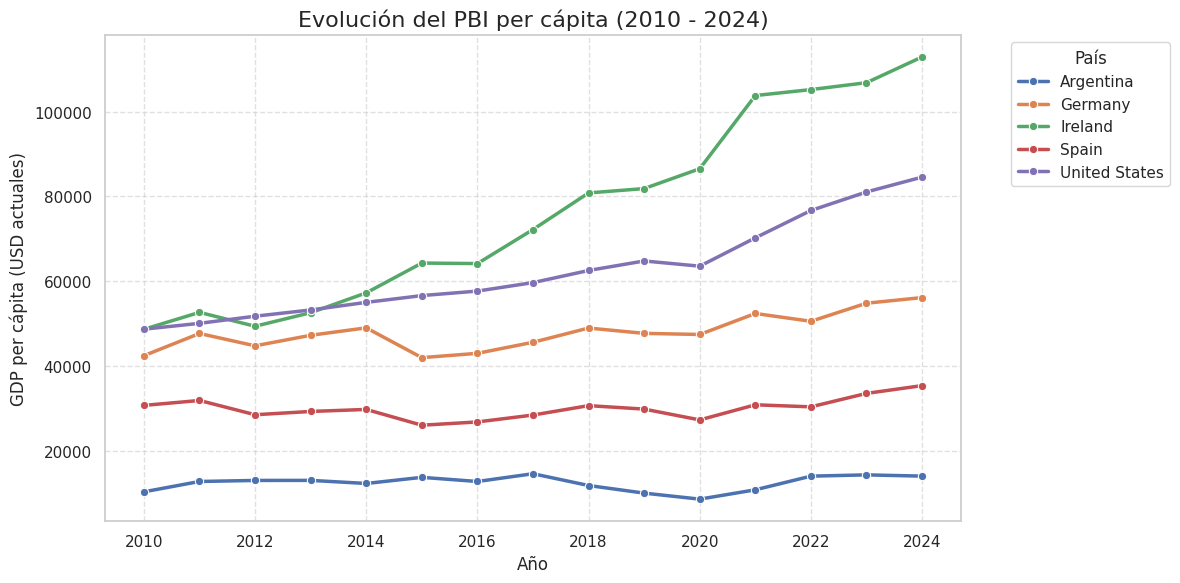

In [9]:
plt.figure(figsize=(12, 6))

# 2. Crear el gráfico de líneas
# Usamos 'year' en X, 'gdp_per_capita' en Y y diferenciamos por 'country'
sns.lineplot(
    data=df_final, 
    x='year', 
    y='gdp_per_capita', 
    hue='country', 
    marker='o',      # Añade puntos en cada año
    linewidth=2.5
)

# 3. Personalización estética
plt.title('Evolución del PBI per cápita (2010 - 2024)', fontsize=16)
plt.ylabel('GDP per cápita (USD actuales)', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera del gráfico
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

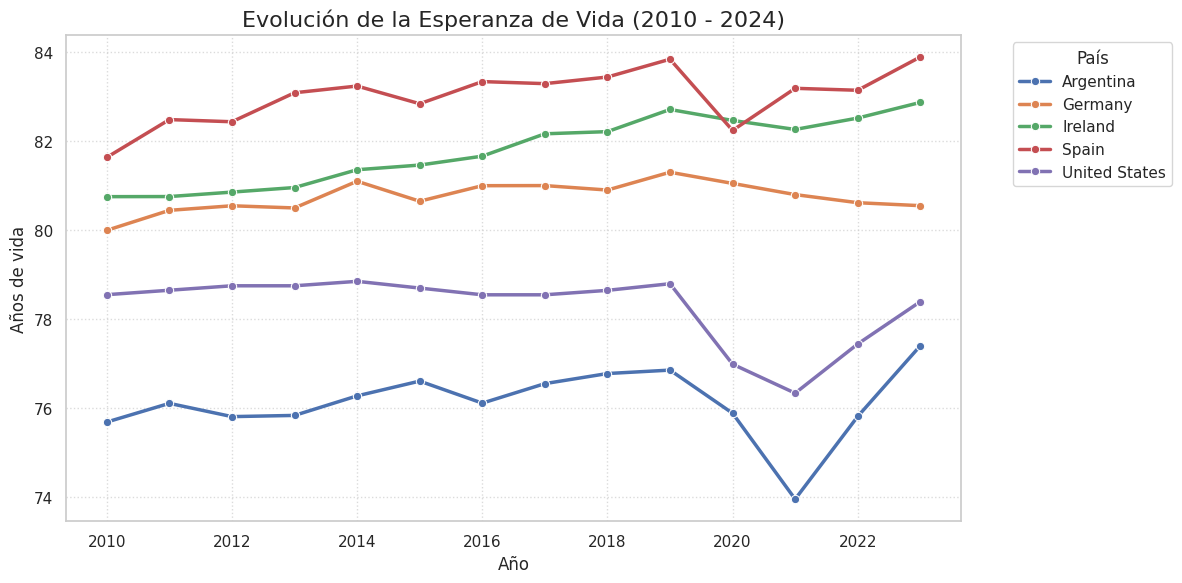

In [11]:
plt.figure(figsize=(12, 6))

# 2. Crear el gráfico de líneas para Esperanza de Vida
sns.lineplot(
    data=df_final, 
    x='year', 
    y='esperanza_vida', 
    hue='country', 
    marker='o',      # Añade puntos en cada año
    linewidth=2.5
)

# 3. Personalización
plt.title('Evolución de la Esperanza de Vida (2010 - 2024)', fontsize=16)
plt.ylabel('Años de vida', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

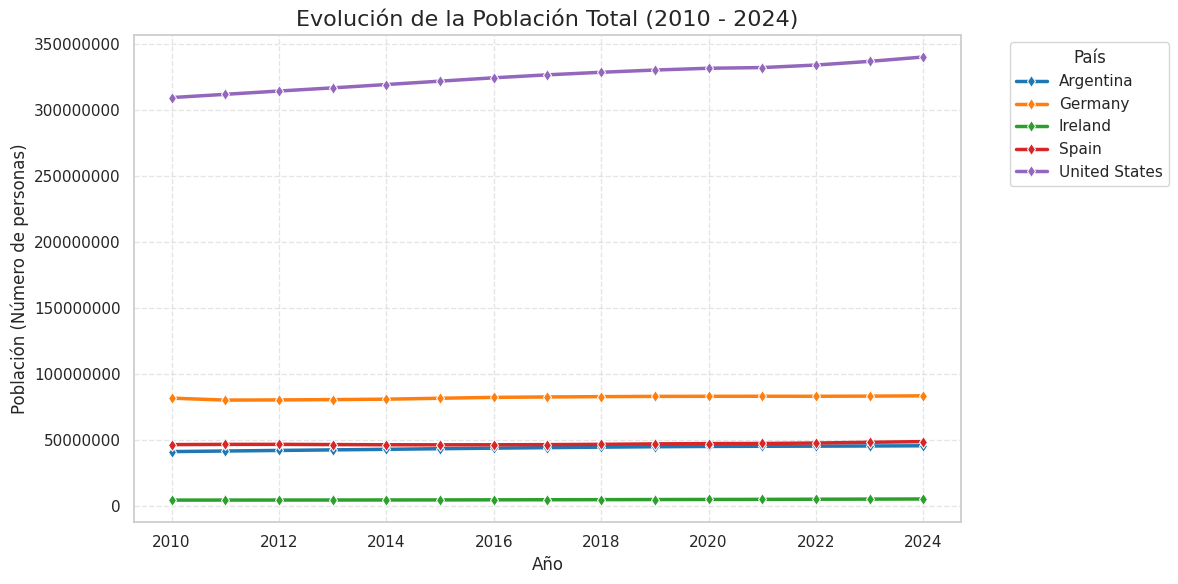

In [10]:
plt.figure(figsize=(12, 6))

# Crear el gráfico de líneas para Población
sns.lineplot(
    data=df_final, 
    x='year', 
    y='poblacion', 
    hue='country', 
    marker='d',       # Diamantes como marcadores
    linewidth=2.5,
    palette='tab10'   # Una paleta con colores bien diferenciados
)

# Personalización
plt.title('Evolución de la Población Total (2010 - 2024)', fontsize=16)
plt.ylabel('Población (Número de personas)', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Opcional: Formatear el eje Y para que no use notación científica
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

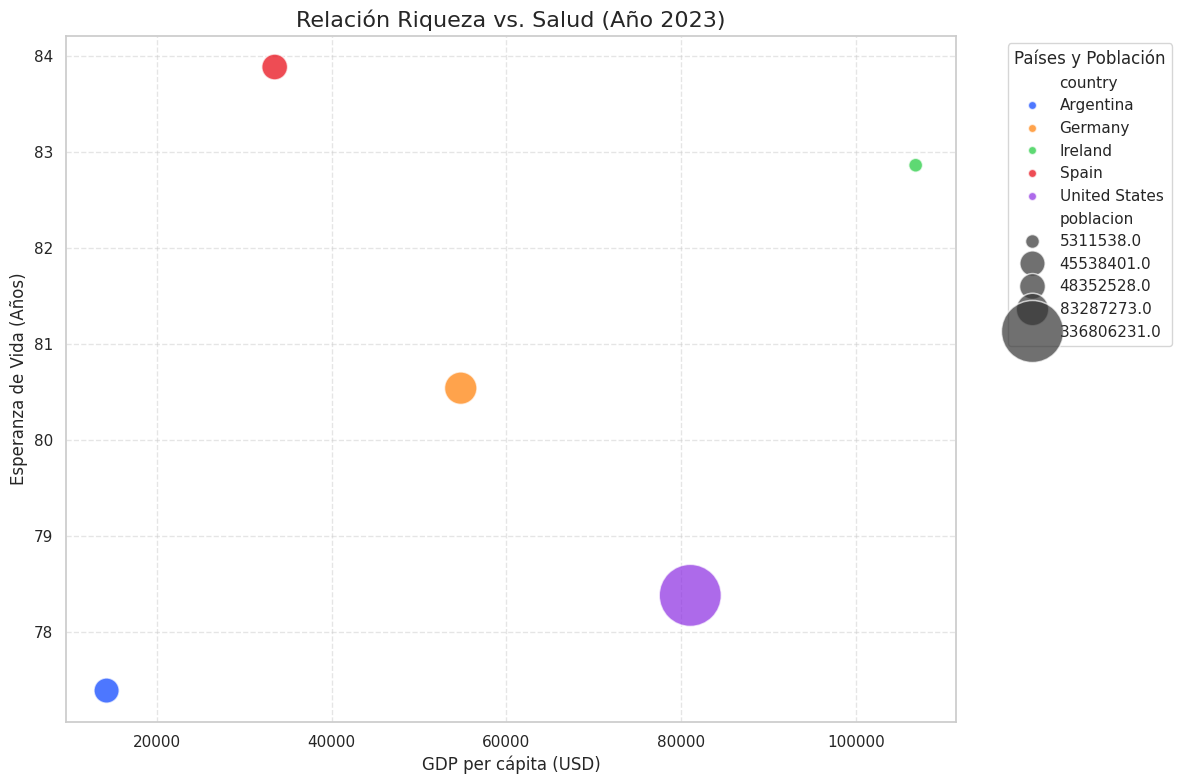

In [12]:
df_reciente = df_final[df_final['year'] == 2023].copy()

# 2. Configurar el gráfico
plt.figure(figsize=(12, 8))

# 3. Crear el gráfico de burbujas
scatter = sns.scatterplot(
    data=df_reciente,
    x='gdp_per_capita',
    y='esperanza_vida',
    size='poblacion',      # El tamaño depende de la población
    hue='country',         # El color depende del país
    sizes=(100, 2000),     # Rango de tamaño de las burbujas
    alpha=0.7,             # Transparencia para ver si se solapan
    palette='bright'
)

# 4. Personalización técnica
plt.title('Relación Riqueza vs. Salud (Año 2023)', fontsize=16)
plt.xlabel('GDP per cápita (USD)', fontsize=12)
plt.ylabel('Esperanza de Vida (Años)', fontsize=12)

# Mover la leyenda para que no estorbe
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Países y Población')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()